# scDeBussy Benchmark Demo

This notebook benchmarks scDeBussy on in-repo synthetic data and compares:

- Baseline: observed local pseudotime (`s_local`)
- scDeBussy: aligned pseudotime (`aligned_pseudotime`)

The workflow includes a compact parameter sweep, quantitative summaries, and inline visual diagnostics.

## 1) Imports and Utilities

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scdebussy
from scdebussy.tl import initialize_structured_loadings, simulate_LF_MOGP

warnings.filterwarnings("ignore", category=UserWarning)


def _safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2 or y.size < 2:
        return np.nan
    x_std = np.std(x)
    y_std = np.std(y)
    if x_std == 0 or y_std == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def evaluate_against_truth(adata, pred_key, truth_key="tau_global", patient_key="patient"):  # noqa: D103
    pred = adata.obs[pred_key].to_numpy(dtype=float)
    truth = adata.obs[truth_key].to_numpy(dtype=float)
    patients = adata.obs[patient_key].to_numpy()

    rmse = float(np.sqrt(np.mean((pred - truth) ** 2)))
    pearson_r = _safe_pearson(pred, truth)

    per_patient = []
    for pid in sorted(pd.unique(patients)):
        mask = patients == pid
        pred_p = pred[mask]
        truth_p = truth[mask]
        per_patient.append(
            {
                "patient": pid,
                "n_cells": int(mask.sum()),
                "pearson_r": _safe_pearson(pred_p, truth_p),
                "rmse": float(np.sqrt(np.mean((pred_p - truth_p) ** 2))),
            }
        )

    return {
        "global": {"pearson_r": pearson_r, "rmse": rmse},
        "per_patient": pd.DataFrame(per_patient),
    }


def validate_required_obs(adata, required_keys=("patient", "s_local", "tau_global")):  # noqa: D103
    missing = [k for k in required_keys if k not in adata.obs]
    if missing:
        raise ValueError(f"Missing required obs fields: {missing}")

    s_local = adata.obs["s_local"].to_numpy(dtype=float)
    if np.any(~np.isfinite(s_local)):
        raise ValueError("s_local contains non-finite values.")
    if np.min(s_local) < 0 or np.max(s_local) > 1:
        raise ValueError("s_local must lie in [0, 1].")

    return True

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## 2) Generate Synthetic Benchmark Data

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

K = 100
P = 5
M = 4
time_grid = np.linspace(0, 1, 200)
factor_kernels = [{"lengthscale": 0.10, "variance": 1.0} for _ in range(M)]
deviation_kernel = {"lengthscale": 0.15, "variance": 0.20}
patient_groups = ["full", "early", "late", "transition", "bimodal"]
eps = 0.01
warp_strength = 0.1
warp_mode = "random_monotone"

W, gene_categories = initialize_structured_loadings(K=K, M=M, rng=rng, strength=1.0)

adata = simulate_LF_MOGP(
    K=K,
    P=P,
    M=M,
    time_grid=time_grid,
    factor_kernels=factor_kernels,
    deviation_kernel=deviation_kernel,
    W=W,
    gene_categories=gene_categories,
    patient_groups=patient_groups,
    lambda_cells=150,
    sigma_noise=0.05,
    rng=rng,
    eps=eps,
    warp_strength=warp_strength,
    warp_mode=warp_mode,
)

validate_required_obs(adata)
print("adata shape:", adata.shape)
print("patients:", sorted(adata.obs["patient"].unique()))
print("patient groups:", sorted(adata.obs["patient_group"].unique()))
print("s_local range:", (float(adata.obs["s_local"].min()), float(adata.obs["s_local"].max())))

adata shape: (734, 100)
patients: ['patient_0', 'patient_1', 'patient_2', 'patient_3', 'patient_4']
patient groups: ['bimodal', 'early', 'full', 'late', 'transition']
s_local range: (0.0, 1.0)


## 3) Baseline Metrics (Observed Pseudotime)

In [3]:
baseline_metrics = evaluate_against_truth(adata, pred_key="s_local")
print("Baseline global metrics")
print(baseline_metrics["global"])
baseline_metrics["per_patient"]

Baseline global metrics
{'pearson_r': 0.8507429596587532, 'rmse': 0.18946239685917882}


,patient,n_cells,pearson_r,rmse
0,patient_0,154,0.998927,0.014818
1,patient_1,149,0.999408,0.029780
2,patient_2,143,0.999389,0.402228
3,patient_3,134,0.997978,0.150164
4,patient_4,154,0.999976,0.012625


## 4) scDeBussy Parameter Sweep

In [4]:
param_grid = [
    {"n_bins": 60, "bandwidth": 0.08, "gamma": 0.10, "max_iter": 15},
    {"n_bins": 80, "bandwidth": 0.10, "gamma": 0.10, "max_iter": 15},
    {"n_bins": 100, "bandwidth": 0.10, "gamma": 0.20, "max_iter": 15},
    {"n_bins": 120, "bandwidth": 0.12, "gamma": 0.20, "max_iter": 15},
]

sweep_rows = []
best_adata = None
best_row = None

for i, params in enumerate(param_grid, start=1):
    adata_run = adata.copy()
    adata_run = scdebussy.tl.scDeBussy(
        adata_run,
        patient_key="patient",
        pseudotime_key="s_local",
        n_bins=params["n_bins"],
        bandwidth=params["bandwidth"],
        gamma=params["gamma"],
        max_iter=params["max_iter"],
        tol=1e-4,
        key_added="aligned_pseudotime",
        barycenter_key="barycenter",
        verbose=False,
    )

    metrics = evaluate_against_truth(adata_run, pred_key="aligned_pseudotime")
    row = {
        "run": i,
        **params,
        "pearson_r": metrics["global"]["pearson_r"],
        "rmse": metrics["global"]["rmse"],
    }
    sweep_rows.append(row)

    if best_row is None:
        best_row = row
        best_adata = adata_run
    else:
        better = False
        if row["pearson_r"] > best_row["pearson_r"]:
            better = True
        elif np.isclose(row["pearson_r"], best_row["pearson_r"]) and row["rmse"] < best_row["rmse"]:
            better = True

        if better:
            best_row = row
            best_adata = adata_run

sweep_df = pd.DataFrame(sweep_rows).sort_values(["pearson_r", "rmse"], ascending=[False, True]).reset_index(drop=True)
sweep_df

,run,n_bins,bandwidth,gamma,max_iter,pearson_r,rmse
0,1,60,0.08,0.1,15,0.957293,0.141271
1,3,100,0.10,0.2,15,0.956841,0.142890
2,2,80,0.10,0.1,15,0.956646,0.142016
3,4,120,0.12,0.2,15,0.955563,0.141854


In [5]:
print("Selected params:", {k: best_row[k] for k in ["n_bins", "bandwidth", "gamma", "max_iter"]})
print("Selected global metrics:", {"pearson_r": best_row["pearson_r"], "rmse": best_row["rmse"]})

aligned_metrics = evaluate_against_truth(best_adata, pred_key="aligned_pseudotime")

summary_df = pd.DataFrame(
    [
        {
            "method": "baseline_s_local",
            "pearson_r": baseline_metrics["global"]["pearson_r"],
            "rmse": baseline_metrics["global"]["rmse"],
        },
        {
            "method": "scDeBussy_aligned",
            "pearson_r": aligned_metrics["global"]["pearson_r"],
            "rmse": aligned_metrics["global"]["rmse"],
        },
    ]
)
summary_df

Selected params: {'n_bins': 60, 'bandwidth': 0.08, 'gamma': 0.1, 'max_iter': 15}
Selected global metrics: {'pearson_r': 0.9572930329388494, 'rmse': 0.14127145707817484}


,method,pearson_r,rmse
0,baseline_s_local,0.850743,0.189462
1,scDeBussy_aligned,0.957293,0.141271


## 5) Visualization A: Alignment Scatter by Patient

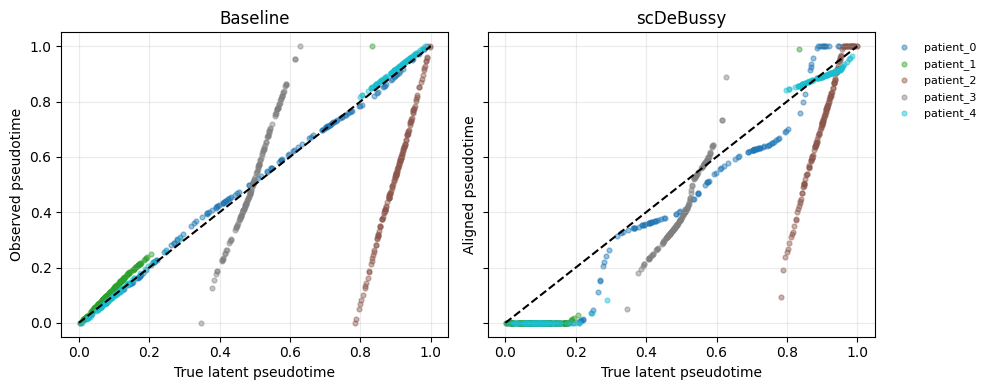

In [6]:
true_tau = best_adata.obs["tau_global"].to_numpy(dtype=float)
observed_tau = best_adata.obs["s_local"].to_numpy(dtype=float)
aligned_tau = best_adata.obs["aligned_pseudotime"].to_numpy(dtype=float)
patients = best_adata.obs["patient"].to_numpy()

patient_ids = sorted(pd.unique(patients))
colors = plt.cm.tab10(np.linspace(0, 1, len(patient_ids)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for c, pid in zip(colors, patient_ids, strict=False):
    mask = patients == pid
    ax1.scatter(true_tau[mask], observed_tau[mask], s=12, alpha=0.45, color=c, label=str(pid))
    ax2.scatter(true_tau[mask], aligned_tau[mask], s=12, alpha=0.45, color=c, label=str(pid))

for ax, title, ylabel in [
    (ax1, "Baseline", "Observed pseudotime"),
    (ax2, "scDeBussy", "Aligned pseudotime"),
]:
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="black")
    ax.set_title(title)
    ax.set_xlabel("True latent pseudotime")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

ax2.legend(frameon=False, fontsize=8, ncols=1, bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

## 6) Visualization B: Cell-Level Error Delta

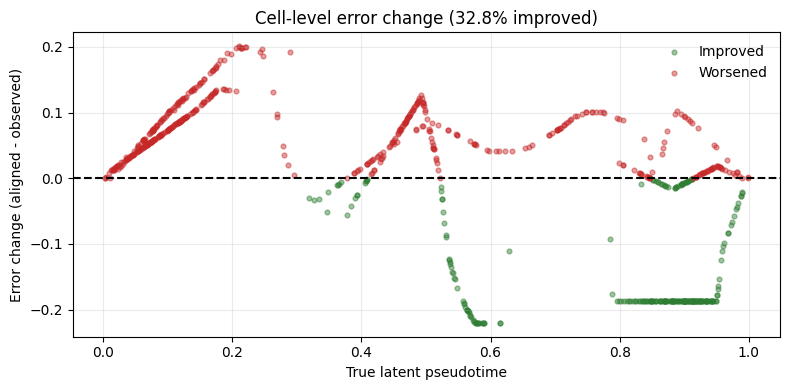

In [7]:
baseline_abs_err = np.abs(observed_tau - true_tau)
aligned_abs_err = np.abs(aligned_tau - true_tau)
error_delta = aligned_abs_err - baseline_abs_err
pct_improved = float(100.0 * np.mean(error_delta < 0))

fig, ax = plt.subplots(figsize=(8, 4))
improved_mask = error_delta < 0
ax.scatter(true_tau[improved_mask], error_delta[improved_mask], s=12, alpha=0.45, color="#2E7D32", label="Improved")
ax.scatter(true_tau[~improved_mask], error_delta[~improved_mask], s=12, alpha=0.45, color="#C62828", label="Worsened")
ax.axhline(0, linestyle="--", linewidth=1.5, color="black")
ax.set_xlabel("True latent pseudotime")
ax.set_ylabel("Error change (aligned - observed)")
ax.set_title(f"Cell-level error change ({pct_improved:.1f}% improved)")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7) Visualization C: Quantitative Summary Panels

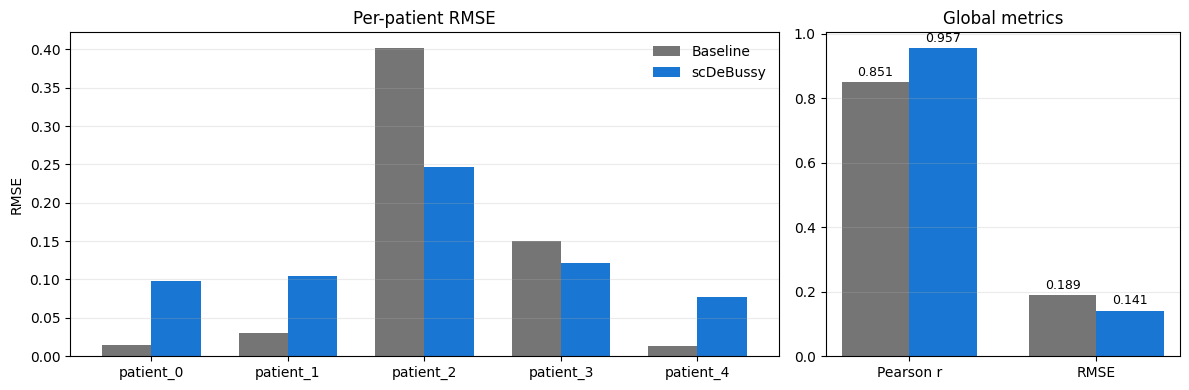

,patient,n_cells,baseline_pearson_r,baseline_rmse,aligned_pearson_r,aligned_rmse,rmse_improvement
0,patient_0,154,0.998927,0.014818,0.981253,0.097430,-0.082612
1,patient_1,149,0.999408,0.029780,0.803417,0.104261,-0.074481
2,patient_2,143,0.999389,0.402228,0.989891,0.246261,0.155967
3,patient_3,134,0.997978,0.150164,0.977327,0.121991,0.028173
4,patient_4,154,0.999976,0.012625,0.995946,0.076491,-0.063866


In [8]:
patient_baseline = baseline_metrics["per_patient"].rename(
    columns={"pearson_r": "baseline_pearson_r", "rmse": "baseline_rmse"}
)
patient_aligned = aligned_metrics["per_patient"].rename(
    columns={"pearson_r": "aligned_pearson_r", "rmse": "aligned_rmse"}
)
patient_df = patient_baseline.merge(
    patient_aligned[["patient", "aligned_pearson_r", "aligned_rmse"]], on="patient", how="inner"
)
patient_df["rmse_improvement"] = patient_df["baseline_rmse"] - patient_df["aligned_rmse"]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2.0, 1.0]})

x = np.arange(len(patient_df))
w = 0.36
ax_left.bar(x - w / 2, patient_df["baseline_rmse"], w, label="Baseline", color="#757575")
ax_left.bar(x + w / 2, patient_df["aligned_rmse"], w, label="scDeBussy", color="#1976D2")
ax_left.set_xticks(x)
ax_left.set_xticklabels(patient_df["patient"], rotation=0)
ax_left.set_ylabel("RMSE")
ax_left.set_title("Per-patient RMSE")
ax_left.grid(axis="y", alpha=0.25)
ax_left.legend(frameon=False)

metric_names = ["Pearson r", "RMSE"]
baseline_vals = [baseline_metrics["global"]["pearson_r"], baseline_metrics["global"]["rmse"]]
aligned_vals = [aligned_metrics["global"]["pearson_r"], aligned_metrics["global"]["rmse"]]
x2 = np.arange(len(metric_names))
ax_right.bar(x2 - w / 2, baseline_vals, w, color="#757575", label="Baseline")
ax_right.bar(x2 + w / 2, aligned_vals, w, color="#1976D2", label="scDeBussy")
ax_right.set_xticks(x2)
ax_right.set_xticklabels(metric_names)
ax_right.set_title("Global metrics")
ax_right.grid(axis="y", alpha=0.25)

for i, (b, a) in enumerate(zip(baseline_vals, aligned_vals, strict=False)):
    ax_right.text(i - w / 2, b + 0.01, f"{b:.3f}", ha="center", va="bottom", fontsize=9)
    ax_right.text(i + w / 2, a + 0.01, f"{a:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

patient_df

## 8) Optional Extension: Add Extra Methods

This section is optional and does not require extra dependencies by default.

To add another method, produce a per-cell prediction vector on the same cells and evaluate it with `evaluate_against_truth` using the same ground-truth key (`tau_global`).

In [ ]:
def evaluate_external_prediction(adata, prediction, method_name="external_method"):  # noqa: D103
    if len(prediction) != adata.n_obs:
        raise ValueError(f"Prediction length {len(prediction)} does not match n_obs={adata.n_obs}.")

    adata_tmp = adata.copy()
    adata_tmp.obs["_external_prediction"] = np.asarray(prediction, dtype=float)
    metrics = evaluate_against_truth(adata_tmp, pred_key="_external_prediction")

    return pd.DataFrame(
        [
            {
                "method": method_name,
                "pearson_r": metrics["global"]["pearson_r"],
                "rmse": metrics["global"]["rmse"],
            }
        ]
    )


# Example placeholder usage (replace with real method predictions):
# fake_pred = best_adata.obs['s_local'].to_numpy()
# evaluate_external_prediction(best_adata, fake_pred, method_name='my_method')

## 9) Reproducibility and Runtime Notes

- A fixed RNG seed is used (`SEED = 42`) for deterministic synthetic data generation.
- The default sweep is intentionally compact for documentation runtime.
- For deeper local exploration, increase grid size (`param_grid`) and optionally add extra methods through the extension cell.